In [5]:
import numpy as np
from numpy.typing import NDArray
from scipy.ndimage import median_filter

from bloodmoon.mask import CodedMaskCamera


def bkg_smoothing(
    detector: NDArray,
    camera: CodedMaskCamera,
    *,
    kernelsize_y: int = 11,
    kernelsize_x: int = 7,
) -> NDArray:
    """
    Performs a smoothing of the residual background from the coded-mask camera detector image.

    The smoothing is performed on the (y, x) axes independently. First, the detector image
    is collapsed along a direction, and then a 1D median filter is applied to remove the
    residual high frequencies on the collapsed array. The median filter is applied ignoring
    the detector sensitivity array zeroes to avoid boundary effects.

    The kernel has a default size along `(y, x)` of `(11 x 7)` at upscaling `(1, 1)`, equal
    to a physical size of `(11 * 0.4, 7 * 0.25) mm` for the Wide Field Monitor cameras.
    Inside the method, the kernel size is automatically adjusted to the camera upscaling. 

    This smoothing should be applied after removing the brightest sources from the original
    detector image (e.g., by processing the observed sky with the IROS algorithm).
    While the remaining (weaker) sources will be affected by the smoothing, it has been
    tested that their significance is reduced by a factor lower than `10%`, for both on-
    and off-axis sources with SNR between `5` and `50` sigmas.

    Args:
        detector (NDArray):
            Input coded-mask camera detector image.
        camera (CodedMaskCamera):
            Instance with detector geometry info.
        kernelsize_y (int, optional (default=`7`)):
            Kernel size along the y axis (upscaling 1).
        kernelsize_x (int, optional (default=`11`)):
            Kernel size along the x axis (upscaling 1).
    
    Returns:
        output (NDArray):
            Smoothed detector image. The array is rescaled to have
            the same counts of the original input detector image.
    
    ## Notes:
        - CFR with url: [`bkg_fitting_v3.ipynb`](
        https://github.com/yuri-evangelista/CodedMasks/blob/main/notebooks/bkg_fitting_v3.ipynb
        ).
    """
    # define median filter kernel size at given camera upscaling
    UPX, UPY = camera.upscale_f
    KERNEL_SIZE = {
        'y': int(kernelsize_y * UPY),
        'x': int(kernelsize_x * UPX),
    }
    
    def apply_filter(axis: int, size: int) -> NDArray:
        """
        Collapses the detector along the specified axis and
        applies a 1D median filter of the given size.
        """
        # collapse detector and bulk
        collapsed_det = detector.sum(axis=axis)
        collapsed_bulk = camera.bulk.sum(axis=axis)
        # bulk zeros are ignored to avoid boundary effects
        bulk_mask = (collapsed_bulk > 0)
        filtered = collapsed_det.copy()
        filtered[bulk_mask] = median_filter(
            collapsed_det[bulk_mask], size=size, mode='nearest',
        )
        return filtered
    
    # apply filter along the two axes independently
    # ! the smoothing is performed by collapsing the
    #   detector along the opposing direction
    smooth_y = apply_filter(axis=1, size=KERNEL_SIZE['y'])
    smooth_x = apply_filter(axis=0, size=KERNEL_SIZE['x'])

    # restore 2D profile through broadcasting (as suggested by np.tile doc)
    # - the smoothed array is masked with the bulk to remove artefacts
    # - the filtered array is rescaled to conserve the original counts
    smoothed = smooth_y[:, np.newaxis] * smooth_x[np.newaxis, :]
    smoothed *= (camera.bulk > 0)
    smoothed *= (detector.sum() / smoothed.sum())

    return smoothed

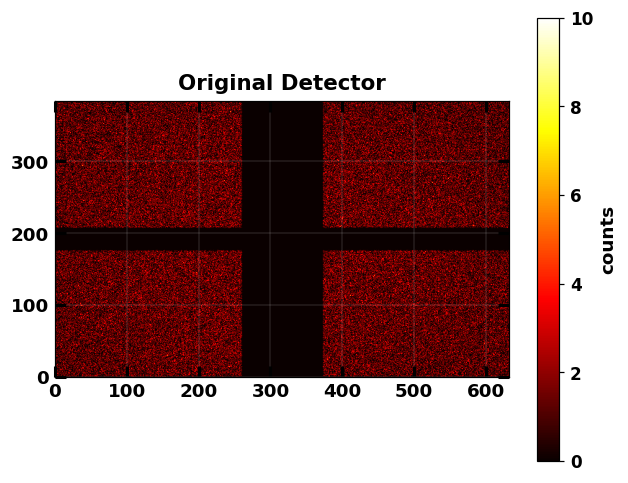

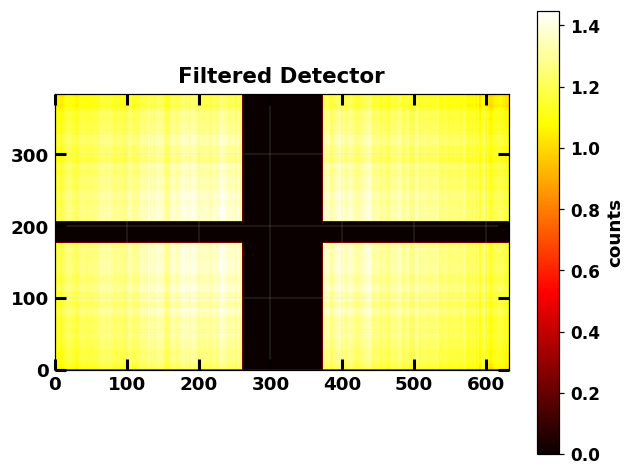

230470.0 230470.0


In [6]:
from bloodmoon.mask import codedmask, count

from darksun.data import get_data
from darksun.show import image_plot

basepath = '/mnt/d/PhD_AASS/Coding/Images_fits'
maskpath = f'{basepath}/wfm_mask_summer2021.fits'
datapath = f'{basepath}/IROSDummy/CXB_1ks_detected_2-50keV.fits'

wfm = codedmask(maskpath, 1, 1)
sdl = get_data(datapath)

detector = count(wfm, sdl.DLdata)[0]

image_plot(
    detector,
    title='Original Detector',
    cbarlabel='counts',
    cmap='hot',
)

filtered = bkg_smoothing(detector, wfm)

image_plot(
    filtered,
    title='Filtered Detector',
    cbarlabel='counts',
    cmap='hot',
)

print(detector.sum(), filtered.sum())

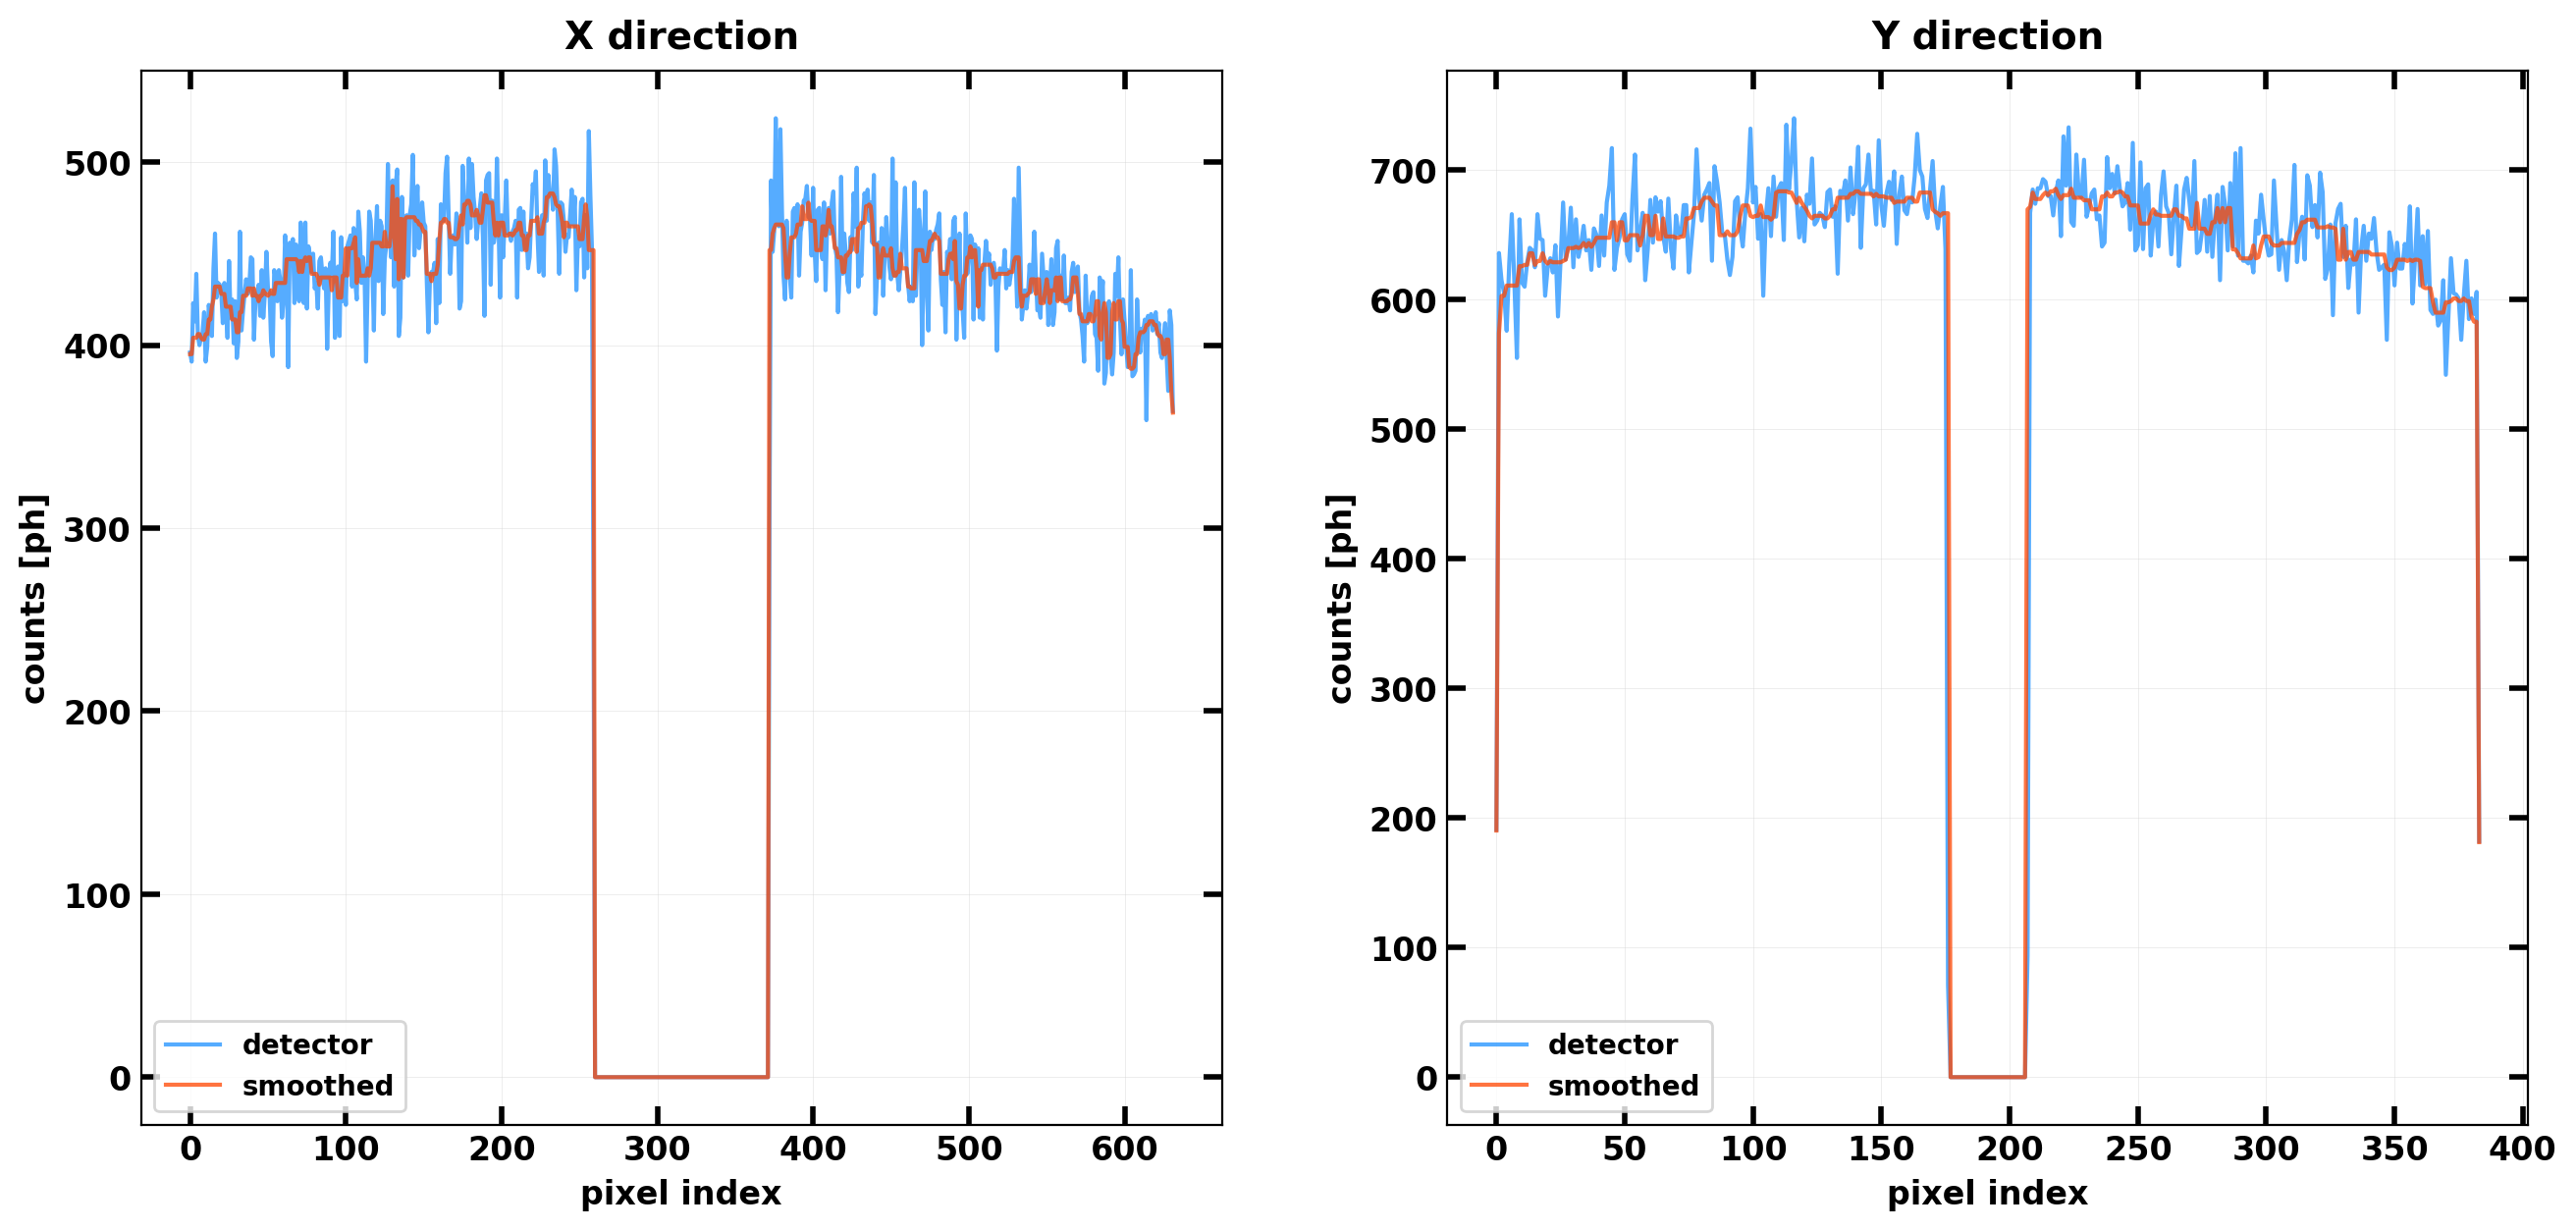

In [7]:
from darksun.show import map4biplot, biplot

collapsed_det_x, collapsed_filtered_x = map(
    lambda x: np.sum(x, axis=0),
    (detector, filtered),
)
dmapx = map4biplot(
    arrs=(collapsed_det_x, collapsed_filtered_x),
    title='X direction',
    ylabel='counts [ph]',
    xlabel='pixel index',
    labels=('detector', 'smoothed'),
    color=('DodgerBlue', 'OrangeRed')
)

collapsed_det_y, collapsed_filtered_y = map(
    lambda x: np.sum(x, axis=1),
    (detector, filtered),
)
dmapy = map4biplot(
    arrs=(collapsed_det_y, collapsed_filtered_y),
    title='Y direction',
    ylabel='counts [ph]',
    xlabel='pixel index',
    labels=('detector', 'smoothed'),
    color=('DodgerBlue', 'OrangeRed')
)

biplot(dmapx, dmapy)

In [8]:
#from darksun.show_trials import plot#, image_plot
#
#plot(dmapx)
#plot(dmaps=(dmapx, dmapy), ncols=2)
#image_plot(
#    filtered,
#    title='Filtered Detector',
#    cbarlabel='counts',
#    cmap='hot',
#)